# **Training a DCGAN on MNIST**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt

# Use the GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Fix the random seed so results are reproducible
torch.manual_seed(42)

Using device: cuda


In [ ]:
latent_dim = 100      # size of the random noise vector fed to the Generator
batch_size = 128      # images per training step
lr = 0.0002           # learning rate (standard for DCGAN)
beta1 = 0.5           # Adam momentum parameter (standard for DCGAN)
num_epochs = 50       # total training epochs
save_epochs = [1, 5, 20, 50]   # epochs at which we save models and sample images

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("samples", exist_ok=True)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),                 # converts image to tensor, pixel range 0..1
    transforms.Normalize((0.5,), (0.5,))   # (x - 0.5) / 0.5  ->  range -1..1
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                    num_workers=2, drop_last=True)

print("Number of images:", len(train_data))
print("Batches per epoch:", len(loader))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.50MB/s]

Number of images: 60000
Batches per epoch: 468


In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (batch, 100, 1, 1) -> Output: (batch, 256, 7, 7)
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # (batch, 256, 7, 7) -> (batch, 128, 14, 14)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (batch, 128, 14, 14) -> (batch, 1, 28, 28)
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()   # squashes output to the range -1..1
        )

    def forward(self, z):
        return self.net(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # (batch, 1, 28, 28) -> (batch, 64, 14, 14)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (batch, 64, 14, 14) -> (batch, 128, 7, 7)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # (batch, 128, 7, 7) -> (batch, 1, 1, 1)  : one score per image
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0, bias=False)
            # No Sigmoid here: the loss function applies it internally
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCEWithLogitsLoss()
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# Same noise every time, so we can watch the SAME "seeds" improve over epochs
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

In [ ]:
#training loop
G_losses, D_losses = [], []

for epoch in range(1, num_epochs + 1):
    epoch_d, epoch_g = 0.0, 0.0

    for real_imgs, _ in loader:          # labels (digits 0-9) are ignored: GAN is unsupervised
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)

        real_labels = torch.ones(b, device=device)
        fake_labels = torch.zeros(b, device=device)

        # ---------- 1) Train Discriminator ----------
        noise = torch.randn(b, latent_dim, 1, 1, device=device)
        fake_imgs = G(noise)

        opt_D.zero_grad()
        loss_real = criterion(D(real_imgs).view(-1), real_labels)          # real should score 1
        loss_fake = criterion(D(fake_imgs.detach()).view(-1), fake_labels) # fake should score 0
        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # ---------- 2) Train Generator ----------
        opt_G.zero_grad()
        loss_G = criterion(D(fake_imgs).view(-1), real_labels)  # G wants D to say "real" (1)
        loss_G.backward()
        opt_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())
        epoch_d += loss_D.item()
        epoch_g += loss_G.item()

    print(f"Epoch [{epoch}/{num_epochs}]  "
          f"D loss: {epoch_d/len(loader):.4f}  G loss: {epoch_g/len(loader):.4f}")

    # ---------- Save checkpoints and sample images at chosen epochs ----------
    if epoch in save_epochs:
        torch.save({"G": G.state_dict(), "D": D.state_dict()},
                   f"checkpoints/dcgan_epoch_{epoch}.pth")
        with torch.no_grad():
            samples = G(fixed_noise).cpu()
        save_image(samples, f"samples/epoch_{epoch}.png",
                   nrow=8, normalize=True, value_range=(-1, 1))

Epoch [1/50]  D loss: 0.6292  G loss: 1.7449
Epoch [2/50]  D loss: 0.5505  G loss: 1.9358
Epoch [3/50]  D loss: 0.7125  G loss: 1.7169
Epoch [4/50]  D loss: 0.8232  G loss: 1.5434
Epoch [5/50]  D loss: 0.8365  G loss: 1.4873
Epoch [6/50]  D loss: 0.8621  G loss: 1.4723
Epoch [7/50]  D loss: 0.8407  G loss: 1.5463
Epoch [8/50]  D loss: 0.7992  G loss: 1.6209
Epoch [9/50]  D loss: 0.8865  G loss: 1.4762
Epoch [10/50]  D loss: 0.8325  G loss: 1.5818
Epoch [11/50]  D loss: 0.8089  G loss: 1.6477
Epoch [12/50]  D loss: 0.8370  G loss: 1.6059
Epoch [13/50]  D loss: 0.8053  G loss: 1.6423
Epoch [14/50]  D loss: 0.8234  G loss: 1.6670
Epoch [15/50]  D loss: 0.8030  G loss: 1.6552
Epoch [16/50]  D loss: 0.8110  G loss: 1.6594
Epoch [17/50]  D loss: 0.8024  G loss: 1.6840
Epoch [18/50]  D loss: 0.7905  G loss: 1.7108
Epoch [19/50]  D loss: 0.7907  G loss: 1.7181
Epoch [20/50]  D loss: 0.7985  G loss: 1.7146
Epoch [21/50]  D loss: 0.7897  G loss: 1.7417
Epoch [22/50]  D loss: 0.8189  G loss: 1.71

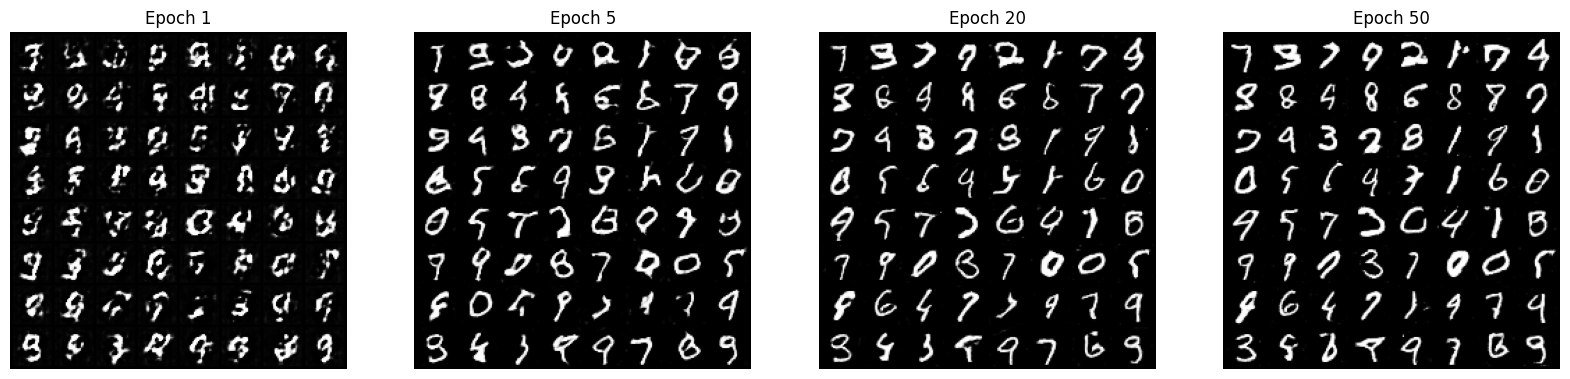

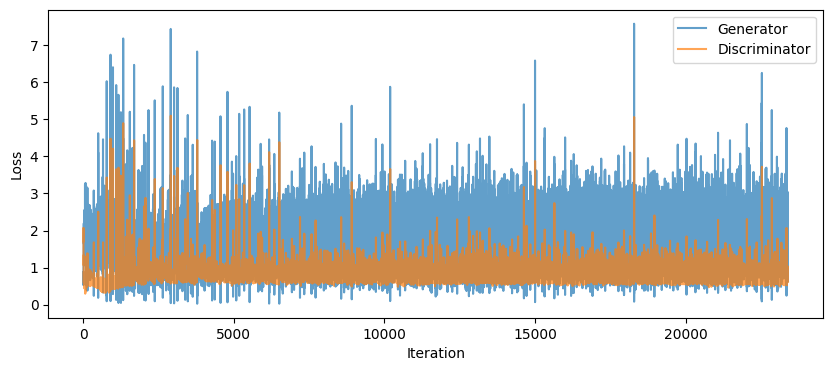

In [ ]:
# Samples at different epochs
fig, axes = plt.subplots(1, len(save_epochs), figsize=(20, 5))
for ax, ep in zip(axes, save_epochs):
    ax.imshow(plt.imread(f"samples/epoch_{ep}.png"))
    ax.set_title(f"Epoch {ep}")
    ax.axis("off")
plt.show()

# Loss curves
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label="Generator", alpha=0.7)
plt.plot(D_losses, label="Discriminator", alpha=0.7)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#saving the checkpoint files to computer

# Bundle both folders into one zip file
!zip -r results.zip checkpoints samples
from google.colab import files
files.download("results.zip")

  adding: checkpoints/ (stored 0%)
  adding: checkpoints/dcgan_epoch_5.pth (deflated 7%)
  adding: checkpoints/dcgan_epoch_20.pth (deflated 7%)
  adding: checkpoints/dcgan_epoch_50.pth (deflated 7%)
  adding: checkpoints/dcgan_epoch_1.pth (deflated 7%)
  adding: samples/ (stored 0%)
  adding: samples/epoch_1.png (deflated 2%)
  adding: samples/epoch_5.png (deflated 3%)
  adding: samples/epoch_20.png (deflated 4%)
  adding: samples/epoch_50.png (deflated 4%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Training unstable GAN to observe mode collapse**

In [ ]:
#measuring diversity
def diversity_score(imgs):
    """Average pairwise distance between images in a batch.
    High = varied images. Low = images look alike (mode collapse)."""
    flat = imgs.reshape(imgs.size(0), -1)        # (N, 1, 28, 28) -> (N, 784)
    dists = torch.cdist(flat, flat)              # (N, N) matrix of distances between every pair
    n = flat.size(0)
    return (dists.sum() / (n * (n - 1))).item()  # diagonal is 0, so divide by the number of real pairs

def generated_diversity(gen, n=128):
    with torch.no_grad():                        # no gradients needed, we only generate
        fake = gen(torch.randn(n, latent_dim, 1, 1, device=device))
    return diversity_score(fake)

# Baseline: how diverse is the REAL data?
real_batch, _ = next(iter(loader))
real_div = diversity_score(real_batch.to(device))
print(f"Real MNIST diversity: {real_div:.2f}")

Real MNIST diversity: 20.38


In [ ]:
#building the bad setup:
g_steps = 5            # Generator updates per ONE Discriminator update
lr_G_bad = 0.001       # Generator learning rate (high)
lr_D_bad = 0.00005     # Discriminator learning rate (very low)
unstable_epochs = 20
unstable_save = [1, 5, 10, 20]

# A deliberately small Discriminator (few channels, no BatchNorm)
class WeakDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 4, 2, 1), nn.LeakyReLU(0.2, True),    # 28x28 -> 14x14
            nn.Conv2d(8, 16, 4, 2, 1), nn.LeakyReLU(0.2, True),   # 14x14 -> 7x7
            nn.Conv2d(16, 1, 7, 1, 0)                             # 7x7 -> 1 score
        )
    def forward(self, x):
        return self.net(x)

G_bad = Generator(latent_dim).to(device)       # same Generator class as before
D_bad = WeakDiscriminator().to(device)
G_bad.apply(weights_init)
D_bad.apply(weights_init)

opt_G_bad = optim.Adam(G_bad.parameters(), lr=lr_G_bad, betas=(beta1, 0.999))
opt_D_bad = optim.Adam(D_bad.parameters(), lr=lr_D_bad, betas=(beta1, 0.999))

In [ ]:
#training the unstable GAN:
G_bad_losses, D_bad_losses = [], []

for epoch in range(1, unstable_epochs + 1):
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)
        real_labels = torch.ones(b, device=device)
        fake_labels = torch.zeros(b, device=device)

        # ---------- ONE Discriminator update ----------
        noise = torch.randn(b, latent_dim, 1, 1, device=device)
        fake_imgs = G_bad(noise)

        opt_D_bad.zero_grad()
        loss_D = criterion(D_bad(real_imgs).view(-1), real_labels) + \
                 criterion(D_bad(fake_imgs.detach()).view(-1), fake_labels)
        loss_D.backward()
        opt_D_bad.step()

        # ---------- FIVE Generator updates (this is what destabilizes it) ----------
        for _ in range(g_steps):
            noise = torch.randn(b, latent_dim, 1, 1, device=device)   # fresh noise each time
            opt_G_bad.zero_grad()
            loss_G = criterion(D_bad(G_bad(noise)).view(-1), real_labels)
            loss_G.backward()
            opt_G_bad.step()

        G_bad_losses.append(loss_G.item())
        D_bad_losses.append(loss_D.item())

    print(f"Epoch [{epoch}/{unstable_epochs}]  D loss: {loss_D.item():.3f}  "
          f"G loss: {loss_G.item():.3f}  Diversity: {generated_diversity(G_bad):.2f} "
          f"(real: {real_div:.2f})")

    if epoch in unstable_save:
        torch.save({"G": G_bad.state_dict(), "D": D_bad.state_dict()},
                   f"checkpoints/unstable_epoch_{epoch}.pth")
        with torch.no_grad():
            samples = G_bad(fixed_noise).cpu()
        save_image(samples, f"samples/unstable_epoch_{epoch}.png",
                   nrow=8, normalize=True, value_range=(-1, 1))

Epoch [1/20]  D loss: 1.388  G loss: 0.692  Diversity: 2.20 (real: 20.38)
Epoch [2/20]  D loss: 1.386  G loss: 0.693  Diversity: 2.53 (real: 20.38)
Epoch [3/20]  D loss: 1.386  G loss: 0.694  Diversity: 1.63 (real: 20.38)
Epoch [4/20]  D loss: 1.387  G loss: 0.693  Diversity: 2.79 (real: 20.38)
Epoch [5/20]  D loss: 1.387  G loss: 0.693  Diversity: 2.44 (real: 20.38)
Epoch [6/20]  D loss: 1.387  G loss: 0.692  Diversity: 3.05 (real: 20.38)
Epoch [7/20]  D loss: 1.386  G loss: 0.693  Diversity: 2.74 (real: 20.38)
Epoch [8/20]  D loss: 1.386  G loss: 0.694  Diversity: 2.41 (real: 20.38)
Epoch [9/20]  D loss: 1.386  G loss: 0.693  Diversity: 3.02 (real: 20.38)
Epoch [10/20]  D loss: 1.386  G loss: 0.693  Diversity: 1.87 (real: 20.38)
Epoch [11/20]  D loss: 1.386  G loss: 0.693  Diversity: 2.91 (real: 20.38)
Epoch [12/20]  D loss: 1.386  G loss: 0.693  Diversity: 2.51 (real: 20.38)
Epoch [13/20]  D loss: 1.386  G loss: 0.693  Diversity: 3.05 (real: 20.38)
Epoch [14/20]  D loss: 1.386  G lo

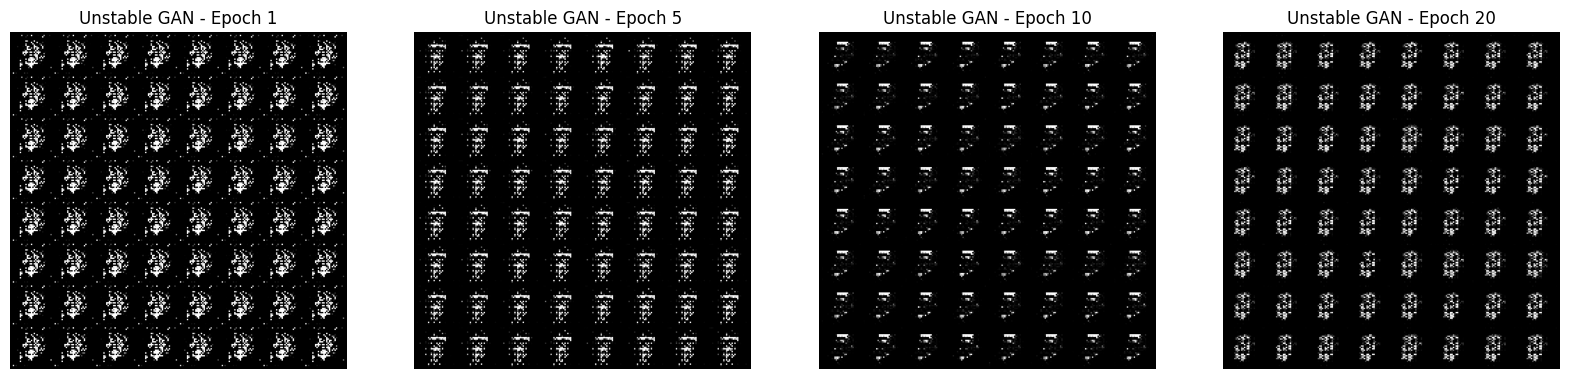

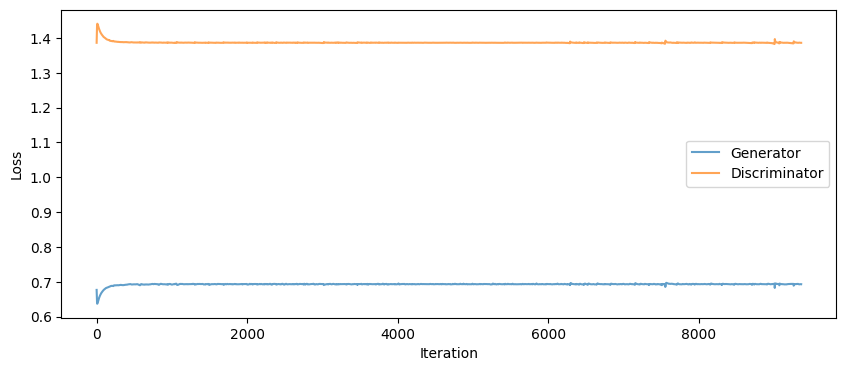

In [ ]:
#visualizing results:
fig, axes = plt.subplots(1, len(unstable_save), figsize=(20, 5))
for ax, ep in zip(axes, unstable_save):
    ax.imshow(plt.imread(f"samples/unstable_epoch_{ep}.png"))
    ax.set_title(f"Unstable GAN - Epoch {ep}")
    ax.axis("off")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(G_bad_losses, label="Generator", alpha=0.7)
plt.plot(D_bad_losses, label="Discriminator", alpha=0.7)
plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.legend()
plt.show()

# **WGAN-GP**

In [ ]:
# The Discriminator becomes a "Critic": same shape, but NO BatchNorm and NO sigmoid
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), nn.LeakyReLU(0.2, True),     # 28 -> 14
            nn.Conv2d(64, 128, 4, 2, 1), nn.LeakyReLU(0.2, True),   # 14 -> 7
            nn.Conv2d(128, 1, 7, 1, 0)                              # 7 -> 1 raw score
        )
    def forward(self, x):
        return self.net(x)

def gradient_penalty(critic, real, fake):
    b = real.size(0)
    eps = torch.rand(b, 1, 1, 1, device=device)           # random number in 0..1 per image
    interp = (eps * real + (1 - eps) * fake).requires_grad_(True)   # points BETWEEN real and fake

    scores = critic(interp)                               # critic's score at those points

    grads = torch.autograd.grad(
        outputs=scores,                                   # differentiate the scores...
        inputs=interp,                                    # ...with respect to the input images
        grad_outputs=torch.ones_like(scores),             # needed because scores is not a single number
        create_graph=True,                                # keep the graph so we can backprop THROUGH this gradient
        retain_graph=True
    )[0]

    grads = grads.reshape(b, -1)                          # one flat gradient vector per image
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()         # penalize deviation of gradient norm from 1
    return gp

# ---- WGAN-GP settings ----
n_critic = 5          # critic updates per Generator update
lambda_gp = 10        # weight of the gradient penalty
wgan_epochs = 30
wgan_save = [1, 5, 15, 30]

G_w = Generator(latent_dim).to(device)    # same Generator architecture
C = Critic().to(device)
G_w.apply(weights_init)
C.apply(weights_init)

# WGAN-GP paper settings: lower LR and beta1 = 0
opt_Gw = optim.Adam(G_w.parameters(), lr=0.0001, betas=(0.0, 0.9))
opt_C = optim.Adam(C.parameters(), lr=0.0001, betas=(0.0, 0.9))

In [ ]:
W_estimates = []     # estimate of Wasserstein distance (real score - fake score)
step = 0

for epoch in range(1, wgan_epochs + 1):
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)

        # ---------- Critic update (every batch) ----------
        noise = torch.randn(b, latent_dim, 1, 1, device=device)
        with torch.no_grad():
            fake_imgs = G_w(noise)               # no gradients to G needed here

        opt_C.zero_grad()
        score_real = C(real_imgs).mean()         # average score on real images
        score_fake = C(fake_imgs).mean()         # average score on fake images
        gp = gradient_penalty(C, real_imgs, fake_imgs)
        loss_C = score_fake - score_real + lambda_gp * gp   # critic wants real HIGH, fake LOW
        loss_C.backward()
        opt_C.step()

        W_estimates.append((score_real - score_fake).item())

        # ---------- Generator update (every n_critic batches) ----------
        step += 1
        if step % n_critic == 0:
            noise = torch.randn(b, latent_dim, 1, 1, device=device)
            opt_Gw.zero_grad()
            loss_G = -C(G_w(noise)).mean()       # G wants the critic to score its fakes HIGH
            loss_G.backward()
            opt_Gw.step()

    print(f"Epoch [{epoch}/{wgan_epochs}]  W-estimate: {W_estimates[-1]:.3f}  "
          f"Diversity: {generated_diversity(G_w):.2f} (real: {real_div:.2f})")

    if epoch in wgan_save:
        torch.save({"G": G_w.state_dict(), "C": C.state_dict()},
                   f"checkpoints/wgangp_epoch_{epoch}.pth")
        with torch.no_grad():
            samples = G_w(fixed_noise).cpu()
        save_image(samples, f"samples/wgan_epoch_{epoch}.png",
                   nrow=8, normalize=True, value_range=(-1, 1))

Epoch [1/30]  W-estimate: 14.127  Diversity: 8.22 (real: 20.38)
Epoch [2/30]  W-estimate: 4.406  Diversity: 17.47 (real: 20.38)
Epoch [3/30]  W-estimate: 2.781  Diversity: 19.58 (real: 20.38)
Epoch [4/30]  W-estimate: 1.892  Diversity: 19.92 (real: 20.38)
Epoch [5/30]  W-estimate: 2.839  Diversity: 20.31 (real: 20.38)
Epoch [6/30]  W-estimate: 2.538  Diversity: 20.02 (real: 20.38)
Epoch [7/30]  W-estimate: 2.216  Diversity: 20.29 (real: 20.38)
Epoch [8/30]  W-estimate: 2.670  Diversity: 20.49 (real: 20.38)
Epoch [9/30]  W-estimate: 2.364  Diversity: 20.17 (real: 20.38)
Epoch [10/30]  W-estimate: 2.175  Diversity: 19.89 (real: 20.38)
Epoch [11/30]  W-estimate: 1.842  Diversity: 20.42 (real: 20.38)
Epoch [12/30]  W-estimate: 1.769  Diversity: 19.98 (real: 20.38)
Epoch [13/30]  W-estimate: 1.630  Diversity: 20.35 (real: 20.38)
Epoch [14/30]  W-estimate: 1.442  Diversity: 20.14 (real: 20.38)
Epoch [15/30]  W-estimate: 1.393  Diversity: 20.08 (real: 20.38)
Epoch [16/30]  W-estimate: 1.218  

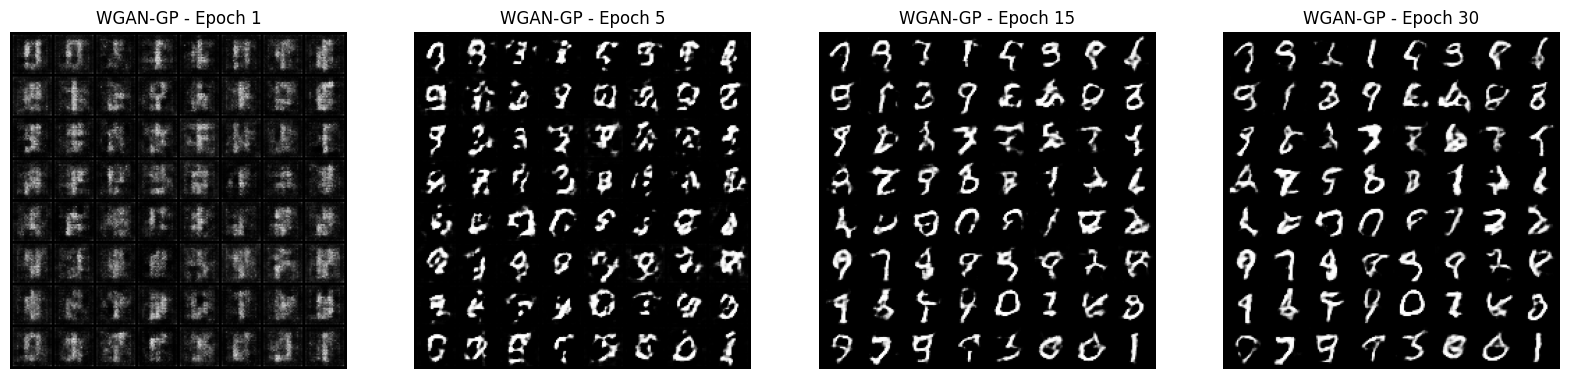

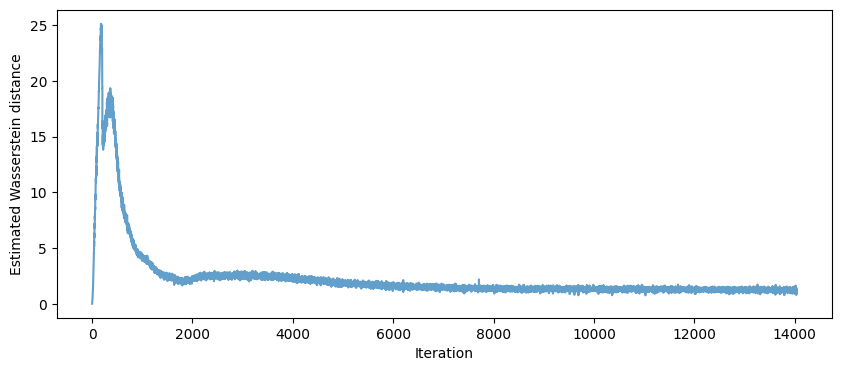

In [ ]:
#results:
fig, axes = plt.subplots(1, len(wgan_save), figsize=(20, 5))
for ax, ep in zip(axes, wgan_save):
    ax.imshow(plt.imread(f"samples/wgan_epoch_{ep}.png"))
    ax.set_title(f"WGAN-GP - Epoch {ep}")
    ax.axis("off")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(W_estimates, alpha=0.7)
plt.xlabel("Iteration"); plt.ylabel("Estimated Wasserstein distance")
plt.show()

In [ ]:
from google.colab import files
import zipfile

uploaded = files.upload()   # file picker opens

for name in uploaded:       # loop over whatever is uploaded
    if name.endswith(".zip"):
        with zipfile.ZipFile(name) as z:
            z.extractall(".")   # unpack into checkpoints/ and samples/ (adds the DCGAN files, keeps today's)

!ls checkpoints samples

Saving results.zip to results.zip
checkpoints:
dcgan_epoch_1.pth   unstable_epoch_10.pth  wgangp_epoch_15.pth
dcgan_epoch_20.pth  unstable_epoch_1.pth   wgangp_epoch_1.pth
dcgan_epoch_50.pth  unstable_epoch_20.pth  wgangp_epoch_30.pth
dcgan_epoch_5.pth   unstable_epoch_5.pth   wgangp_epoch_5.pth

samples:
epoch_1.png   epoch_5.png	     unstable_epoch_20.png  wgan_epoch_1.png
epoch_20.png  unstable_epoch_10.png  unstable_epoch_5.png   wgan_epoch_30.png
epoch_50.png  unstable_epoch_1.png   wgan_epoch_15.png	    wgan_epoch_5.png


Real data          : 20.38
DCGAN (epoch 50)   : 20.30
Unstable GAN       : 2.78
WGAN-GP            : 19.95


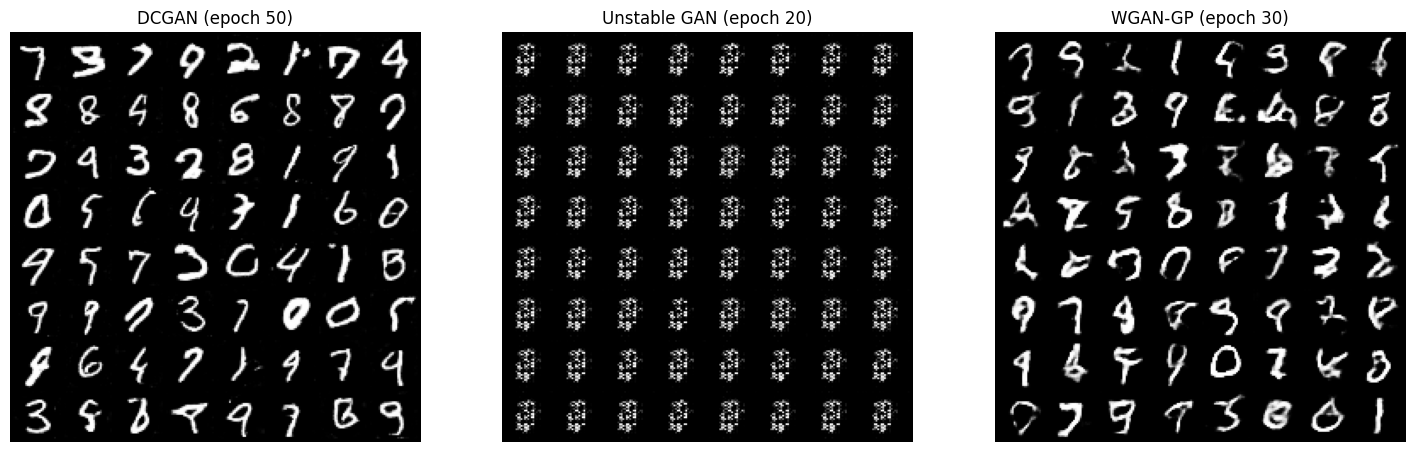

In [ ]:
import os
from torchvision.utils import make_grid

# 1) Rebuild a fresh Generator and load the saved DCGAN weights into it
dcgan_path = "checkpoints/dcgan_epoch_50.pth"
assert os.path.exists(dcgan_path), "dcgan_epoch_50.pth not found - run the upload cell first"

G_dcgan = Generator(latent_dim).to(device)                      # same architecture as when it was trained
ckpt = torch.load(dcgan_path, map_location=device)              # map_location loads onto the current device
G_dcgan.load_state_dict(ckpt["G"])                              # copy the saved weights into the model

# 2) Diversity numbers
print(f"Real data          : {real_div:.2f}")
print(f"DCGAN (epoch 50)   : {generated_diversity(G_dcgan):.2f}")
print(f"Unstable GAN       : {generated_diversity(G_bad):.2f}")
print(f"WGAN-GP            : {generated_diversity(G_w):.2f}")

# 3) Generate all three grids from the SAME fixed noise, so the comparison is fair
models = [("DCGAN (epoch 50)", G_dcgan),
          ("Unstable GAN (epoch 20)", G_bad),
          ("WGAN-GP (epoch 30)", G_w)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (title, gen) in zip(axes, models):
    with torch.no_grad():
        imgs = gen(fixed_noise).cpu()                                       # 64 images
    grid = make_grid(imgs, nrow=8, normalize=True, value_range=(-1, 1))     # arrange into 8x8 grid
    ax.imshow(grid.permute(1, 2, 0))                                        # (C,H,W) -> (H,W,C) for matplotlib
    ax.set_title(title)
    ax.axis("off")
plt.show()

## Summary

Three GAN variants were trained on MNIST and compared using sample grids from the same fixed noise and a diversity score (average pairwise pixel distance between generated images; real MNIST scores 20.38). A standard DCGAN trained for 50 epochs, with checkpoints saved at epochs 1, 5, 20 and 50 from a single run, improved from blurry blobs to clean digits and reached a diversity of 20.30, so no mode collapse occurred. The unstable GAN (very weak, slow Discriminator, high Generator learning rate, 5 Generator updates per Discriminator update) collapsed completely: every noise input produced the same speckled non-digit pattern, diversity was only 2.78, and the losses froze at ln 2 and 2 ln 2, meaning the Discriminator was reduced to guessing and gave no useful feedback.

WGAN-GP (Critic with gradient penalty, 5 Critic updates per Generator update, 30 epochs) trained stably without collapse. Diversity reached the real-data level by epoch 5 (19.95 at the end), and the estimated Wasserstein distance fell from about 14 to about 1.2, a more interpretable training signal than the standard GAN loss. Its digits are rougher than the 50-epoch DCGAN, partly because the Generator receives far fewer updates, and the diversity score measures variety rather than image quality, so visual inspection remains necessary. The runs also used different epoch counts (50, 20 and 30), and the unstable GAN was deliberately configured to fail.